# 8. Core Microbiota Analysis
In this notebook the goal is to understand how the core microbiota differs between breast-fed infants (diet_milk = "bd") and formula-fed infants (diet_milk = "fd"). Core microbiota refers to the genera that appear in most individuals of a group, and it can highlight which microbes are typical or characteristic for each feeding type.

To study this, the feature table is first prepared by rarefying, filtering out very low-abundance taxa, and collapsing the data to genus level. The table is then split into BD and FD groups, and core features are identified for each group across a range of prevalence thresholds. Exploring these thresholds helps show how stable certain genera are and how quickly others drop out as the definition of “core” becomes stricter.

Finally, the BD and FD results are combined to compare which genera are shared between the groups and which are specific to one feeding type. This gives a clearer picture of the microbial signatures linked to breast-feeding versus formula feeding.

### Notebook Structure

**1.** Core Extraction and Table Preparation

**2.** Exploring Core Thresholds

&nbsp;&nbsp;&nbsp;&nbsp;**2.1** Core Size per Group

&nbsp;&nbsp;&nbsp;&nbsp;**2.2** Core Size Compared Between Groups

**3.** Core Taxa Comparison Using Heatmap Between Groups

## Import data & packages

In [1]:
# 1 - Import packages
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import seaborn as sns
import os
from qiime2 import Visualization
from ipywidgets import Dropdown, VBox, HBox

%matplotlib inline

In [2]:
# 2 - Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# 3 - Data directories
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
core_microbiota_dir = "../data/processed/core_microbiota"
# Create the new differential abundance analysis folder

In [4]:
%%bash -s "$core_microbiota_dir"
mkdir -p "$1"

In [5]:
%%bash -s "$core_microbiota_dir/processed_tables"
mkdir -p "$1"

This widget beneath lets you choose the taxonomic level (e.g. Genus or Family) at which the microbiome will be analyzed.
You also select a metadata variable to split the samples into categories.
After choosing a metadata column, the two dropdowns allow you to pick two groups to compare.
Comparing two groups is necessary because the core-microbiota analysis evaluates which taxa are core in one group, the other group, or shared between them.
The defaults are filled automatically, but you can change all options as needed.

In [6]:
# Load metadata table
metadata = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Taxonomic levels the user can choose from
tax_levels = ["phylum", "class", "order", "family", "genus", "species"]

tax_selector = Dropdown(
    options=tax_levels,
    value="genus",        # default choice
    description="Tax level:"
)

# Metadata columns that are categorical and suitable for grouping
categorical_cols = ["geo_location_name", "delivery_mode", "sex", "diet_milk", "treatment_exposure"]

meta_selector = Dropdown(
    options=sorted(categorical_cols),
    value="diet_milk",    # default grouping variable
    description="Metadata:"
)

# Dropdowns for selecting the two groups to compare
group1_selector = Dropdown(description="Group 1:")
group2_selector = Dropdown(description="Group 2:")

def update_groups(change=None):
    # Get all unique values for the selected metadata column
    col = meta_selector.value
    vals = sorted(metadata[col].dropna().unique().tolist())

    group1_selector.options = vals
    group2_selector.options = vals

    # Pick sensible default groups (first two categories)
    if len(vals) >= 2:
        group1_selector.value = vals[0]
        group2_selector.value = vals[1]
    elif len(vals) == 1:
        group1_selector.value = vals[0]
        group2_selector.value = vals[0]

# Update groups whenever the metadata column selection changes
meta_selector.observe(update_groups, names="value")

# Initial population of the dropdowns
update_groups()

# Display the widget interface
VBox([
    tax_selector,
    meta_selector,
    HBox([group1_selector, group2_selector])
])

In [7]:
# Read current selections from the widgets
selected_level = tax_selector.value
group_col = meta_selector.value
group1 = group1_selector.value
group2 = group2_selector.value

# Convenience list for filtering and looping
groups = [group1, group2]

## 1. Core Extraction and Table Preparation

In this section the feature table is first rarefied to an even sequencing depth so that samples become comparable. After optional filtering of extremely low-abundance features, the data are collapsed to genus level. From this standardized table, separate BD and FD subsets are created, and the core-features command is run to identify which genera qualify as core at a basic prevalence threshold. This provides the foundation for all later comparisons.

In [8]:
metadata_fp=f"{meta_data_dir}/metadata_merged.tsv"
feature_table_fp=f"{denoised_data_dir}/dada2_table.qza"
taxonomy_fp=f"{taxonomy_data_dir}/taxonomy.qza"

Samples are rarefied to an even sequencing depth here. Rarefaction removes depth-related bias and makes all samples comparable for presence/absence–based analyses such as core-microbiota detection. Any sample below 14k reads will be dropped automatically.

In [9]:
! qiime feature-table rarefy \
  --i-table "$feature_table_fp" \
  --p-sampling-depth 14000 \
  --o-rarefied-table $core_microbiota_dir/processed_tables/rarefied_14k.qza

! echo "Rarefied table ready: rarefied_14k.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/rarefied_14k.qza
Rarefied table ready: rarefied_14k.qza


This step removes features based on a relative abundance cutoff.
The table was first rarefied, and then this filter keeps only the features that reach at least 1% relative abundance (0.01) in at least one sample. Very low-abundance genera tend to be unstable, inconsistent across samples, or simply sequencing noise. Applying this threshold helps simplify the table so that the core-microbiota results focus on taxa that are more biologically meaningful and not just trace-level detections.

In [10]:
! qiime feature-table filter-features-conditionally \
  --i-table $core_microbiota_dir/processed_tables/rarefied_14k.qza \
  --p-abundance 0.01 \
  --p-prevalence 0 \
  --o-filtered-table $core_microbiota_dir/processed_tables/rarefied_14k_min01.qza

! echo "Low-abundance features removed. Table: rarefied_14k_min01.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/rarefied_14k_min01.qza
Low-abundance features removed. Table: rarefied_14k_min01.qza


This step collapses the filtered, rarefied table to genus level using the taxonomy assignments. Working at genus level makes the core-microbiota results easier to interpret and reduces noise from ASV-level variation. The output is a cleaner table where each row represents a genus rather than individual sequence variants.

In [11]:
# Map taxonomic labels to QIIME --p-level numbers
qiime_level_map = {
    "kingdom": 1,
    "phylum": 2,
    "class": 3,
    "order": 4,
    "family": 5,
    "genus": 6,
    "species": 7
}

# Use the widget's selection to compute the QIIME level
qiime_p_level = qiime_level_map[selected_level]

qiime_p_level

6

In [12]:
! qiime taxa collapse \
  --i-table $core_microbiota_dir/processed_tables/rarefied_14k_min01.qza \
  --i-taxonomy "$taxonomy_fp" \
  --p-level {qiime_p_level} \
  --o-collapsed-table $core_microbiota_dir/processed_tables/table_{selected_level}.qza

print(f"{selected_level} table ready: table_{selected_level}.qza")

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/table_genus.qza
genus table ready: table_genus.qza


This cell splits the genus-level table into two separate feature tables based on feeding type. The metadata file contains a diet_milk column that labels each infant as breast-fed (bd) or formula-fed (fd). Using this column, the table is filtered so that one version contains only BD samples and the other contains only FD samples. Creating these separate tables is important because the core-features analysis needs to be run within each feeding group to compare their core microbiota later on.

In [13]:
# Create a table for each category
for value in groups:
    safe_value = str(value).replace(" ", "_").replace("/", "_")
    out_fp = f"{core_microbiota_dir}/processed_tables/table_{selected_level}_{group_col}_{safe_value}.qza"

    print(f"Creating: {out_fp}")

    ! qiime feature-table filter-samples \
        --i-table $core_microbiota_dir/processed_tables/table_{selected_level}.qza \
        --m-metadata-file $metadata_fp \
        --p-where "{group_col}='{value}'" \
        --o-filtered-table {out_fp}

Creating: ../data/processed/core_microbiota/processed_tables/table_genus_diet_milk_bd.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/table_genus_diet_milk_bd.qza
Creating: ../data/processed/core_microbiota/processed_tables/table_genus_diet_milk_fd.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processe

This step identifies the core microbiota within each feeding group. The minimum fraction is set to 0.50, meaning a genus must appear in at least half of the samples to qualify as core. The visualization produced by this command also reports results for higher prevalence thresholds, so starting with a relatively low cutoff makes it easier to explore how the core set changes as the threshold becomes more strict. Running the command separately for the BD and FD tables allows direct comparison between the two feeding groups.

In [14]:
for value in groups:
    safe_value = str(value).replace(" ", "_").replace("/", "_")

    in_fp = f"{core_microbiota_dir}/processed_tables/table_{selected_level}_{group_col}_{safe_value}.qza"
    out_fp = f"{core_microbiota_dir}/core_{selected_level}_{group_col}_{safe_value}_50.qzv"

    ! qiime feature-table core-features \
        --i-table {in_fp} \
        --p-min-fraction 0.50 \
        --o-visualization {out_fp}

print("Core microbiota visualizations created.")

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/core_microbiota/core_genus_diet_milk_bd_50.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/core_microbiota/core_genus_diet_milk_fd_50.qzv
Core microbiota visualizations created.


## 2. Exploring Core Thresholds

In this section the core-features results are examined across a range of prevalence thresholds. The idea is to see how many genera remain “core” as the minimum fraction of samples increases. Lower thresholds capture genera that are common but not universal, while higher thresholds highlight only the most consistently present taxa. Exploring this trend helps understand how stable each genus is in the dataset and gives an overview of how strict the core definition can be before most taxa drop out.

### 2.1. Core Size per Feeding Group

In [15]:
for value in groups:
    safe_value = str(value).replace(" ", "_").replace("/", "_")
    
    vis_fp = f"{core_microbiota_dir}/core_{selected_level}_{group_col}_{safe_value}_50.qzv"
    print(f"Showing visualization for group: {value}")
    
    vis = Visualization.load(vis_fp)
    display(vis)   # This creates a separate output block per visualization

Showing visualization for group: bd


<visualization: Visualization uuid: 51778ac9-48d7-4e3a-b781-80c2d2bfbfa1>

Showing visualization for group: fd


<visualization: Visualization uuid: d659a7dc-b96d-4589-8a1b-1732782790e8>

### 2.2. Core Size Compared Between Groups

This section combines the core-feature results from the BD and FD groups so they can be compared side by side. The exported TSV files from QIIME contain the core genera at each threshold, and by loading them into Python, it becomes possible to plot how the core size changes across thresholds in both groups. This gives a first overview of how stable the microbiota is in BD versus FD infants.

This cell exports the BD and FD core-feature results from their QIIME visualizations. The exported TSV files contain the list of core genera at every threshold included in the visualization. These files will be loaded into Python so both feeding groups can be compared directly.

In [16]:
for value in groups:
    safe_value = str(value).replace(" ", "_").replace("/", "_")

    in_fp = f"{core_microbiota_dir}/core_{selected_level}_{group_col}_{safe_value}_50.qzv"
    out_dir = f"{core_microbiota_dir}/core_{selected_level}_{group_col}_{safe_value}_export"

    print(f"Exporting: {in_fp} → {out_dir}")

    ! qiime tools export \
        --input-path {in_fp} \
        --output-path {out_dir}

    print(f"Export complete for group: {value}\n")

Exporting: ../data/processed/core_microbiota/core_genus_diet_milk_bd_50.qzv → ../data/processed/core_microbiota/core_genus_diet_milk_bd_export
Exported ../data/processed/core_microbiota/core_genus_diet_milk_bd_50.qzv as Visualization to directory ../data/processed/core_microbiota/core_genus_diet_milk_bd_export
Export complete for group: bd

Exporting: ../data/processed/core_microbiota/core_genus_diet_milk_fd_50.qzv → ../data/processed/core_microbiota/core_genus_diet_milk_fd_export
Exported ../data/processed/core_microbiota/core_genus_diet_milk_fd_50.qzv as Visualization to directory ../data/processed/core_microbiota/core_genus_diet_milk_fd_export
Export complete for group: fd



This function loads a core-feature TSV file while skipping QIIME’s comment lines. Some tables include empty rows, so those are removed as well. Each file must contain a “Feature ID” column with the genus names. The function returns a clean DataFrame that can be stored per threshold.

In [17]:
def load_core_file(path):
    """Load a QIIME core-features TSV file and return a cleaned DataFrame."""
    df = pd.read_csv(path, sep="\t", comment="#", dtype=str).dropna(how="all")
    if "Feature ID" not in df.columns:
        raise ValueError(f"'Feature ID' column missing in: {path}")
    return df

core_files = {}

for value in groups:
    safe = str(value).replace(" ", "_").replace("/", "_")
    pattern = f"{core_microbiota_dir}/core_{selected_level}_{group_col}_{safe}_export/core-features-*.tsv"
    core_files[value] = sorted(glob.glob(pattern))
    print(f"{value}: {core_files[value]}")

core_files

bd: ['../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.500.tsv', '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.550.tsv', '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.600.tsv', '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.650.tsv', '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.700.tsv', '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.750.tsv', '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.800.tsv', '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.850.tsv']
fd: ['../data/processed/core_microbiota/core_genus_diet_milk_fd_export/core-features-0.500.tsv', '../data/processed/core_microbiota/core_genus_diet_milk_fd_export/core-features-0.550.tsv', '../data/processed/core_microbiota/core_genus_diet_milk_fd_export/core

{'bd': ['../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.500.tsv',
  '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.550.tsv',
  '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.600.tsv',
  '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.650.tsv',
  '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.700.tsv',
  '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.750.tsv',
  '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.800.tsv',
  '../data/processed/core_microbiota/core_genus_diet_milk_bd_export/core-features-0.850.tsv'],
 'fd': ['../data/processed/core_microbiota/core_genus_diet_milk_fd_export/core-features-0.500.tsv',
  '../data/processed/core_microbiota/core_genus_diet_milk_fd_export/core-features-0.550.tsv',
  '../data/processed/core_microbiota/core_genus

This cell loads all BD and FD core-feature files and stores them in dictionaries, using the threshold extracted from each filename as the key. After loading, the thresholds are sorted and the number of core genera at each threshold is calculated. These values are used to compare how the core size changes across thresholds for the two feeding groups.

In [18]:
core_data = {}   # e.g. { 'bd': {0.5: df, 0.7: df}, 'fd': {...} }

for g in groups:
    safe = str(g).replace(" ", "_").replace("/", "_")
    pattern = f"{core_microbiota_dir}/core_{selected_level}_{group_col}_{safe}_export/core-features-*.tsv"
    files = sorted(glob.glob(pattern))

    group_dict = {}
    for f in files:
        thr = float(re.findall(r"core-features-(.*).tsv", f)[0])
        group_dict[thr] = load_core_file(f)

    core_data[g] = group_dict


# Optional: get threshold → count table for each group
threshold_counts = {
    g: {
        thr: len(df)
        for thr, df in core_data[g].items()
    }
    for g in core_data
}

This plot shows how the number of core genera decreases as the prevalence threshold becomes stricter. Plotting BD and FD together makes it easy to see whether one group has a more stable core microbiota than the other. This visualization provides a high-level comparison before looking at which genera differ specifically.

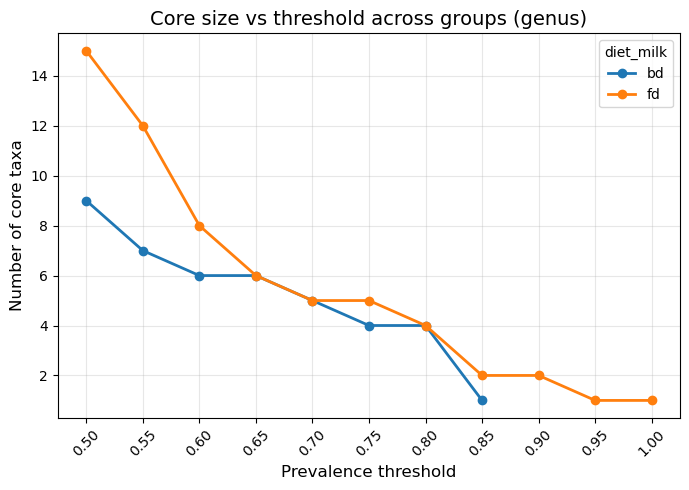

In [19]:
plt.figure(figsize=(7,5))

# Sort thresholds globally (ensures x-axis order is stable)
all_thresholds = sorted({thr for g in threshold_counts for thr in threshold_counts[g]})

for group, thr_dict in threshold_counts.items():
    thr = sorted(thr_dict.keys())
    counts = [thr_dict[t] for t in thr]
    plt.plot(thr, counts, marker="o", linewidth=2, label=str(group))

plt.xlabel("Prevalence threshold", fontsize=12)
plt.ylabel("Number of core taxa", fontsize=12)
plt.title(f"Core size vs threshold across groups ({selected_level})", fontsize=14)
plt.xticks(all_thresholds, rotation=45)
plt.legend(title=group_col)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Core Taxa Comparison Between Breast-Fed and Formula-Fed Infants

This section combines the BD and FD core-microbiota results to see which genera are shared and which are specific to one feeding group. The goal is to track how these patterns change as the prevalence threshold becomes stricter. To do this, genus names are extracted, a matrix is created to label each genus as shared, BD-only, FD-only, or not core, and the results are visualized in a heatmap.

This helper function extracts the genus name from the taxonomy strings in the exported tables. It ensures consistent labeling before combining BD and FD results.

In [20]:
def extract_taxon(taxon_str, level):
    """
    Extract the taxon name corresponding to a QIIME-style taxonomy string.
    E.g., for level = "Genus", extract the part after 'g__'.
    """
    prefixes = {
        "phylum":  "p__",
        "class":   "c__",
        "order":   "o__",
        "family":  "f__",
        "genus":   "g__",
        "species": "s__"
    }
    
    prefix = prefixes[level]

    if prefix not in taxon_str:
        return "Unassigned"
    
    # return the part after the prefix (e.g., "g__Bacteroides")
    return taxon_str.split(prefix)[-1].strip()

Only thresholds that appear in both BD and FD are used for comparison. A lower cutoff (≥0.60) is chosen so genera are not lost too quickly. Genera that appear in either group at the cutoff level are included in the comparison.

In [23]:
common_thresholds = sorted(
    set(group1_core_data.keys()) & set(group2_core_data.keys())
)

# Only show thresholds ≥ 0.60 (your choice)
show_thresholds = [t for t in common_thresholds if t >= 0.60]
thr_labels = [f"{t:.2f}" for t in show_thresholds]

# Core-feature results for the two selected groups
group1_core_data = core_data[group1]
group2_core_data = core_data[group2]

# Cutoff used to decide which taxa to focus on
cutoff = 0.65

# Taxa that are core in each group at the cutoff threshold
group1_taxa_cut = set(group1_core_data[cutoff]["Feature ID"])
group2_taxa_cut = set(group2_core_data[cutoff]["Feature ID"])

# Union of taxa that are core in at least one group
important_taxa = sorted(group1_taxa_cut | group2_taxa_cut)

# Convert feature IDs to taxon names for the selected taxonomic level
important_names = sorted(
    extract_taxon(t, selected_level) for t in important_taxa
)

A matrix is created where each genus is labeled at every threshold as BD-only, FD-only, shared, or not core. This forms the basis of the final comparison heatmap.

In [24]:
# Start matrix: rows = taxa, columns = thresholds, filled with zeros
status_df = pd.DataFrame(0, index=important_names, columns=thr_labels)

for thr, thr_label in zip(show_thresholds, thr_labels):

    # Taxa that are core in group 1 at this threshold
    g1_tax = {extract_taxon(t, selected_level)
              for t in group1_core_data[thr]["Feature ID"]}

    # Taxa that are core in group 2 at this threshold
    g2_tax = {extract_taxon(t, selected_level)
              for t in group2_core_data[thr]["Feature ID"]}

    # Assign categories: 3 = both, 1 = group1-only, 2 = group2-only
    for name in important_names:
        if name in g1_tax and name in g2_tax:
            status_df.loc[name, thr_label] = 3
        elif name in g1_tax:
            status_df.loc[name, thr_label] = 1
        elif name in g2_tax:
            status_df.loc[name, thr_label] = 2

Genera are automatically ordered based on their core-pattern vector so that shared, BD-only, and FD-only genera group together without manual sorting.

In [25]:
# Create a sort key based on each taxon's pattern across thresholds
status_df["sort_key"] = status_df.values.tolist()

# Sort taxa so similar core-patterns appear together in the heatmap
status_df = status_df.sort_values("sort_key", ascending=False)

# Remove the temporary helper column
status_df = status_df.drop(columns=["sort_key"])

A discrete colormap is defined for the four categories in the matrix.

In [26]:
cmap = ListedColormap([
    "#f0f0f0",  # 0 = not core
    "#377eb8",  # 1 = group1-only
    "#ff7f00",  # 2 = group2-only
    "#4daf4a"   # 3 = shared
])

Plot the heatmap

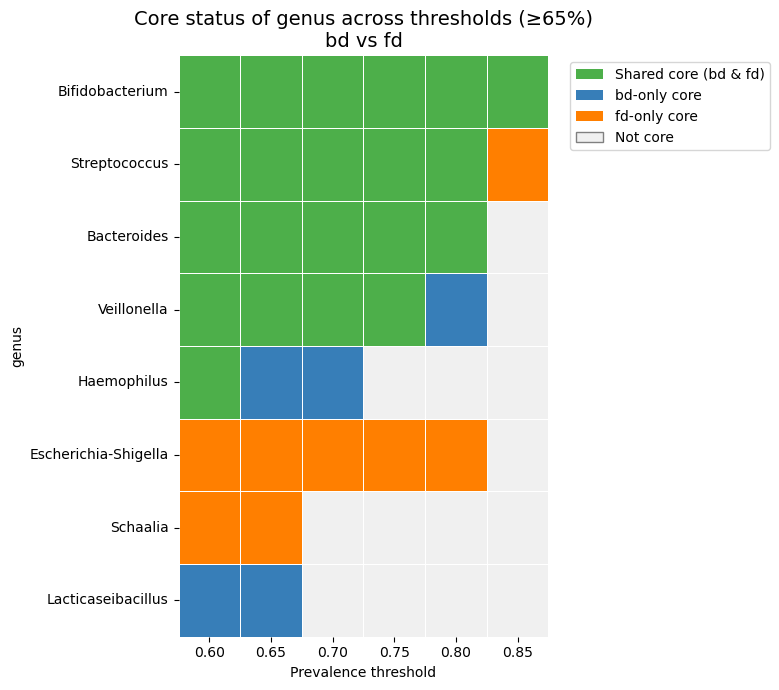

In [27]:
# Define color boundaries for the 4 categories (0, 1, 2, 3)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

# Make the figure height depend on how many taxa we show
plt.figure(figsize=(8, 3 + 0.5*len(important_names)))

# Heatmap showing which taxa are core in each group at each threshold
sns.heatmap(
    status_df,
    cmap=cmap,
    norm=norm,
    cbar=False,
    linewidths=.5,
    linecolor="white"
)

# Title with selected level and group comparison
plt.title(
    f"Core status of {selected_level} across thresholds (≥{int(cutoff*100)}%)\n"
    f"{group1} vs {group2}",
    fontsize=14
)

plt.xlabel("Prevalence threshold")
plt.ylabel(selected_level)

# Legend explaining the four core-status categories
handles = [
    Patch(facecolor="#4daf4a", label=f"Shared core ({group1} & {group2})"),
    Patch(facecolor="#377eb8", label=f"{group1}-only core"),
    Patch(facecolor="#ff7f00", label=f"{group2}-only core"),
    Patch(facecolor="#f0f0f0", edgecolor="gray", label="Not core"),
]

plt.legend(handles=handles, bbox_to_anchor=(1.04, 1), loc="upper left")

plt.tight_layout()
plt.show()


The heatmap shows that *Bifidobacterium* is a stable core genus in both breast-fed (BD) and formula-fed (FD) infants. This suggests that it plays a key role in early gut development, regardless of diet. Previous studies report that *Bifidobacterium* commonly dominates the infant gut, which supports this finding.

Veillonella appears as a core genus in both groups at lower thresholds, but at stricter thresholds it remains core mainly in breast-fed infants. This may be explained by the way breast milk shapes the gut environment. Breast milk promotes strong fermentation by *Bifidobacterium*, which produces lactate. Veillonella can use this lactate, so it may benefit more in infants who receive breast milk. The pattern seen in the heatmap fits this type of cooperative relationship.

In contrast, *Escherichia-Shigella* is consistently part of the core only in formula-fed infants. This suggests that formula feeding creates conditions that support facultative anaerobes. These bacteria are often able to tolerate more oxygen and may thrive when the gut is not as strongly dominated by milk-fermenting species. Many studies have reported higher levels of Enterobacteriaceae in formula-fed infants, which matches the pattern observed here.

Streptococcus and Bacteroides remain shared between the groups across most thresholds. This suggests that some early colonizers are common to all infants and are less influenced by diet. Other genera, such as Haemophilus and Lacticaiseibacillus, appear only at lower thresholds, which suggests that they are not stable enough to be considered core across many infants.

Taken together, these results show that there is a small shared core microbiota in all infants, but diet influences which additional genera become consistently present. Breast-fed infants tend to show a fermentation-based community shaped by milk, while formula-fed infants show higher stability of facultative anaerobes. These differences suggest that feeding mode influences not only which bacteria appear, but also how reliably they colonize the gut.


# References

National Cancer Institute, Center for Cancer Research. QIIME 2: Lesson 7 — Identifying Core Microbiota. https://bioinformatics.ccr.cancer.gov/docs/qiime2/Lesson7/

QIIME 2 Documentation. (2024). core-features: Identify features present in a user-defined fraction of samples. https://docs.qiime2.org/2024.10/plugins/available/feature-table/core-features/
